# Práctica guiada: reducción de dimensionalidad con LLE

Entorno recomendado: Google Colab  
Dataset: Wine de `scikit-learn`

## Resultados de aprendizaje

1. Estandarizar variables medidas en escalas diferentes.
2. Aplicar Locally Linear Embedding para reducir la dimensionalidad.
3. Analizar el efecto del número de vecinos sobre el embedding.
4. Evaluar la preservación local mediante `trustworthiness`.
5. Interpretar una representación bidimensional obtenida con LLE.

## Instrucciones

- Ejecute las celdas en orden.
- Complete únicamente las líneas de código indicadas.
- Responda las preguntas incluidas en las celdas Markdown.
- No cambie los nombres de las variables.
- Ejecute la prueba `assert` después de cada actividad.
- Las etiquetas de clase se utilizarán únicamente para visualizar los resultados y no para ajustar LLE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import LocallyLinearEmbedding, trustworthiness

## 1. Carga y exploración de los datos

In [2]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target.copy()

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [3]:
print("Dimensiones de X:", X.shape)
print("Número de clases:", y.nunique())
display(X.head())

Dimensiones de X: (178, 13)
Número de clases: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
resumen = pd.DataFrame({
    "media": X.mean(),
    "desviación estándar": X.std(),
    "mínimo": X.min(),
    "máximo": X.max()
})

display(resumen.round(3))

,media,desviación estándar,mínimo,máximo
alcohol,13.001,0.812,11.03,14.83
malic_acid,2.336,1.117,0.74,5.80
ash,2.367,0.274,1.36,3.23
alcalinity_of_ash,19.495,3.340,10.60,30.00
magnesium,99.742,14.282,70.00,162.00
total_phenols,2.295,0.626,0.98,3.88
flavanoids,2.029,0.999,0.34,5.08
nonflavanoid_phenols,0.362,0.124,0.13,0.66
proanthocyanins,1.591,0.572,0.41,3.58
color_intensity,5.058,2.318,1.28,13.00


Pregunta 1. ¿Las variables se encuentran en escalas similares? Explique por qué las diferencias de escala pueden afectar la búsqueda de vecinos más cercanos utilizada por LLE.

Respuesta:

## 2. Estandarización

LLE construye vecindarios usando distancias entre las observaciones. Si una variable tiene una escala mucho mayor que las demás, puede dominar el cálculo de esas distancias. Por esta razón, antes de aplicar LLE se estandarizarán las variables.

In [5]:
# ACTIVIDAD 1
# Cree una instancia de StandardScaler y aplíquela sobre X.

#scaler = 
#X_scaled = 

print("Forma de X_scaled:", X_scaled.shape)

Forma de X_scaled: (178, 13)


In [6]:
# PRUEBA 1
assert X_scaled.shape == X.shape
assert np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10)
assert np.allclose(X_scaled.std(axis=0), 1, atol=1e-10)
print("✓ Datos estandarizados correctamente")

✓ Datos estandarizados correctamente


## 3. Aplicación de LLE con dos componentes

En esta primera aplicación se utilizarán 10 vecinos y se reducirá el conjunto de datos a dos dimensiones.

In [7]:
# ACTIVIDAD 2
# Cree un modelo LLE con:
# n_neighbors=10
# n_components=2
# random_state=42

#lle_2d = 

# Aplique el modelo sobre los datos estandarizados.
#X_lle = 

print("Forma de X_lle:", X_lle.shape)

Forma de X_lle: (178, 2)


In [8]:
# PRUEBA 2
assert isinstance(lle_2d, LocallyLinearEmbedding)
assert lle_2d.n_neighbors == 10
assert lle_2d.n_components == 2
assert X_lle.shape == (X.shape[0], 2)
assert np.isfinite(X_lle).all()
print("✓ LLE produjo una representación bidimensional")

✓ LLE produjo una representación bidimensional


Pregunta 2. ¿Qué papel cumple el parámetro `n_neighbors` en LLE? ¿Qué podría ocurrir si se selecciona un valor demasiado pequeño o demasiado grande?

Respuesta:

## 4. Visualización del embedding

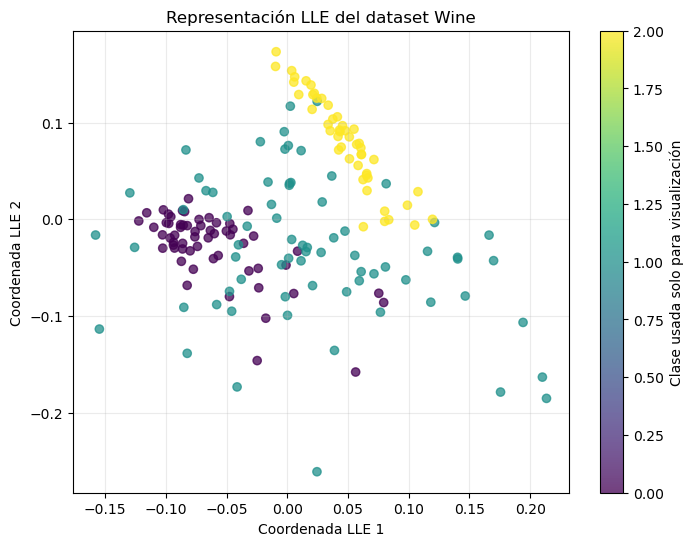

In [9]:
# ACTIVIDAD 3
# Genere un diagrama de dispersión utilizando las dos coordenadas
# almacenadas en X_lle. Utilice la etiqueta de cada ejemplo para asignar color.

plt.figure(figsize=(8, 6))

#scatter = plt.scatter(
#    ,
#    ,
#    c=y,
#    alpha=0.75
#)

plt.xlabel("Coordenada LLE 1")
plt.ylabel("Coordenada LLE 2")
plt.title("Representación LLE del dataset Wine")
plt.grid(alpha=0.25)
plt.colorbar(scatter, label="Clase usada solo para visualización")
plt.show()

In [10]:
# PRUEBA 3
assert X_lle[:, 0].shape[0] == len(y)
assert X_lle[:, 1].shape[0] == len(y)
assert not np.allclose(X_lle[:, 0], X_lle[:, 1])
print("✓ Coordenadas compatibles con la visualización")

✓ Coordenadas compatibles con la visualización


Pregunta 3. Observe la gráfica y responda:

1. ¿Se identifican agrupaciones o regiones diferenciadas?
2. ¿Existen clases que se superponen?
3. ¿La separación visual significa que LLE utilizó las etiquetas durante el ajuste?
4. ¿Qué indica la cercanía entre dos puntos en esta representación?

Respuesta:

## 5. Evaluación del embedding

LLE reporta un error de reconstrucción asociado con su función objetivo. Además, `trustworthiness` permite evaluar si los vecinos observados en el espacio reducido también eran cercanos en el espacio original.

In [11]:
# ACTIVIDAD 4
# Obtenga el error de reconstrucción del modelo ya entrenado.
#error_reconstruccion = 

# Calcule trustworthiness usando 10 vecinos.
#trust_10 = 

print(f"Error de reconstrucción: {error_reconstruccion:.6f}")
print(f"Trustworthiness con 10 vecinos: {trust_10:.4f}")

Error de reconstrucción: 0.000017
Trustworthiness con 10 vecinos: 0.8207


In [12]:
# PRUEBA 4
assert np.isscalar(error_reconstruccion)
assert error_reconstruccion >= 0
assert 0 <= trust_10 <= 1
print("✓ Métricas calculadas correctamente")

✓ Métricas calculadas correctamente


Pregunta 4. Interprete las dos métricas obtenidas.

1. ¿Qué representa el error de reconstrucción en LLE?
2. ¿Qué representa `trustworthiness`?
3. ¿Un valor alto de `trustworthiness` garantiza separación perfecta entre las clases?

Respuesta:

## 6. Efecto del número de vecinos

Ahora se entrenarán varios modelos LLE cambiando el número de vecinos. Todos los modelos mantendrán dos componentes.

In [13]:
# ACTIVIDAD 5
# Complete el ciclo para entrenar un modelo LLE con cada valor de vecinos.

valores_vecinos = [5, 10, 15, 30]
resultados_vecinos = {}
errores_vecinos = {}

#for k in valores_vecinos:
#    modelo = 

#    embedding = 

#    resultados_vecinos[k] = embedding
#    errores_vecinos[k] = modelo.reconstruction_error_

In [15]:
# PRUEBA 5
assert set(resultados_vecinos.keys()) == set(valores_vecinos)
assert set(errores_vecinos.keys()) == set(valores_vecinos)

for k in valores_vecinos:
    assert resultados_vecinos[k].shape == (X.shape[0], 2)
    assert np.isfinite(resultados_vecinos[k]).all()
    assert errores_vecinos[k] >= 0

print("✓ Todos los modelos LLE fueron entrenados")

✓ Todos los modelos LLE fueron entrenados


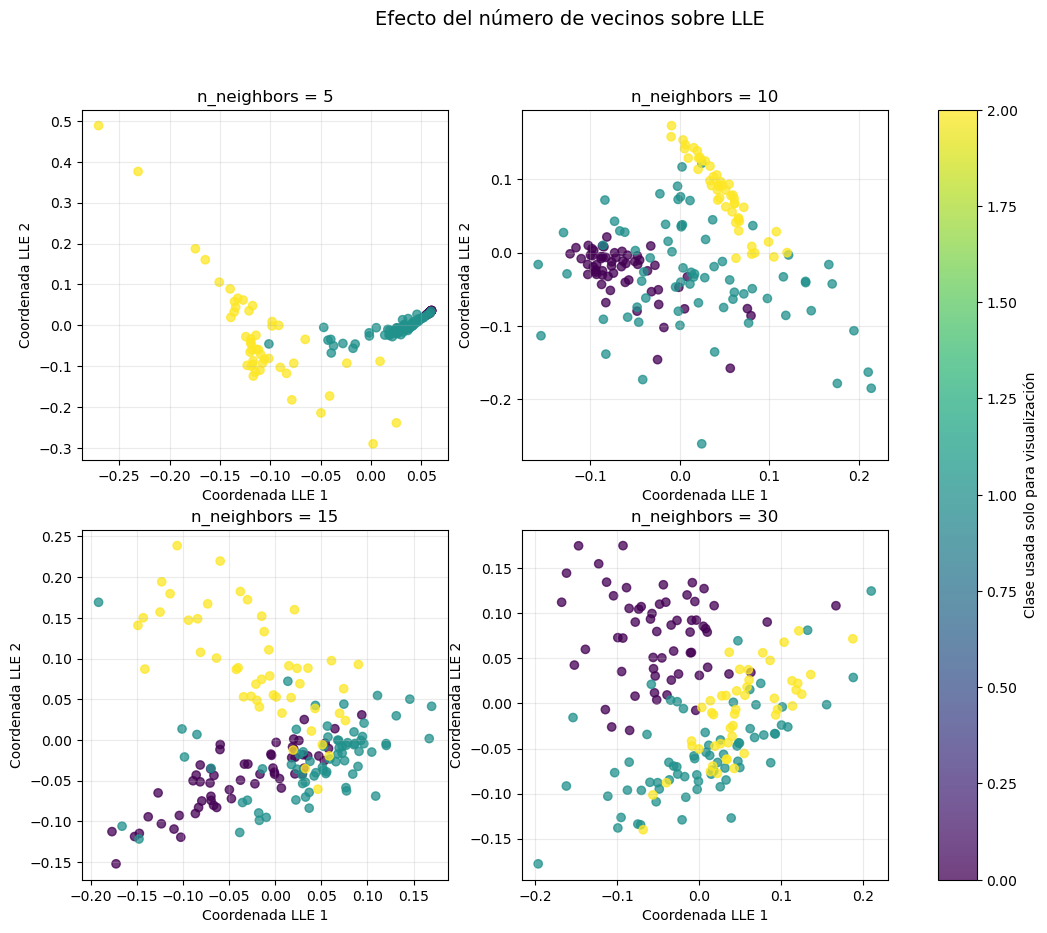

In [16]:
# Visualización de los embeddings obtenidos
fig, ejes = plt.subplots(2, 2, figsize=(13, 10))

for eje, k in zip(ejes.ravel(), valores_vecinos):
    embedding = resultados_vecinos[k]

    scatter = eje.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        alpha=0.75
    )

    eje.set_title(f"n_neighbors = {k}")
    eje.set_xlabel("Coordenada LLE 1")
    eje.set_ylabel("Coordenada LLE 2")
    eje.grid(alpha=0.25)

fig.colorbar(
    scatter,
    ax=ejes.ravel().tolist(),
    label="Clase usada solo para visualización"
)

fig.suptitle("Efecto del número de vecinos sobre LLE", fontsize=14)
plt.show()

Pregunta 5. Compare las cuatro representaciones.

1. ¿Qué cambios observa al aumentar el número de vecinos?
2. ¿Cuál representación conserva mejor estructuras locales claramente diferenciadas?
3. ¿Algún valor parece producir deformaciones, superposiciones o pérdida de detalle?
4. ¿La forma global del embedding permanece estable?

Respuesta:

## 7. Comparación mediante trustworthiness

Para comparar de manera controlada los embeddings, se utilizará el mismo número de vecinos de evaluación en todos los casos. En esta práctica se usará `k_eval = 10`.

Esto significa que cada embedding fue construido con su propio valor de `n_neighbors`, pero todos serán evaluados preguntando qué tan bien conservan vecindarios de tamaño 10.

In [20]:
# ACTIVIDAD 6
# Calcule trustworthiness para cada embedding usando k_eval=10.

k_eval = 10
#trust_scores = {}

#for k in valores_vecinos:
#    valor_trust = 
    
#    trust_scores[k] = valor_trust

print(trust_scores)

{5: np.float64(0.8699291270527225), 10: np.float64(0.8206845289541919), 15: np.float64(0.7721970613656006), 30: np.float64(0.7795540190146931)}


In [21]:
# PRUEBA 6
assert set(trust_scores.keys()) == set(valores_vecinos)

for valor in trust_scores.values():
    assert 0 <= valor <= 1

print("✓ Trustworthiness calculado para todas las configuraciones")

✓ Trustworthiness calculado para todas las configuraciones


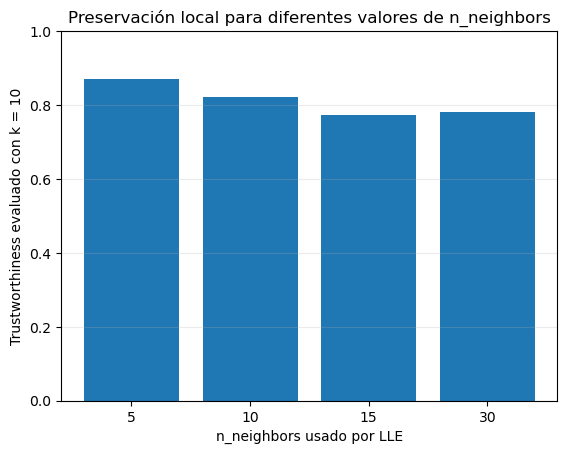

In [22]:
# ACTIVIDAD 7
# Complete las líneas necesarias para construir un diagrama de barras.
# El valor de trustworthiness debe aparecer encima de cada barra.

#valores_trust = 

#plt.figure(figsize=(8, 5))

#barras = plt.bar(
#    ,
#    valores_trust
#)

#for barra, valor in zip(barras, valores_trust):
#    plt.text(
#        barra.get_x() + barra.get_width() / 2,
#        barra.get_height() + 0.01,
#        ,
#        ha="center",
#        va="bottom"
#    )

# En plt.text:
f"{valor:.4f}"

plt.xlabel("n_neighbors usado por LLE")
plt.ylabel(f"Trustworthiness evaluado con k = {k_eval}")
plt.title("Preservación local para diferentes valores de n_neighbors")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.25)
plt.show()

In [23]:
# PRUEBA 7
mejor_k = max(trust_scores, key=trust_scores.get)

assert mejor_k in valores_vecinos
assert np.isclose(trust_scores[mejor_k], max(trust_scores.values()))
print("Configuración con mayor trustworthiness:", mejor_k)

Configuración con mayor trustworthiness: 5


Pregunta 6. Analice la gráfica de `trustworthiness`.

1. ¿Qué configuración obtuvo el valor más alto?
2. ¿La diferencia frente a las demás configuraciones es grande o pequeña?
3. ¿Se observa alguna tendencia al aumentar `n_neighbors`?
4. ¿Puede afirmarse que la configuración con mayor puntuación es siempre la mejor para cualquier propósito?
5. Relacione los resultados cuantitativos con las gráficas de los embeddings.

Respuesta:

## 8. Comparación entre error de reconstrucción y trustworthiness

In [24]:
comparacion = pd.DataFrame({
    "n_neighbors": valores_vecinos,
    "error_reconstruccion": [errores_vecinos[k] for k in valores_vecinos],
    "trustworthiness": [trust_scores[k] for k in valores_vecinos]
})

display(comparacion.round(6))

,n_neighbors,error_reconstruccion,trustworthiness
0,5,0.000409,0.869929
1,10,0.000017,0.820685
2,15,0.000002,0.772197
3,30,0.000012,0.779554


Pregunta 7. Compare ambas métricas.

1. ¿La configuración con menor error de reconstrucción también tiene el mayor `trustworthiness`?
2. ¿Por qué estas dos métricas pueden ordenar de manera diferente las configuraciones?
3. ¿Qué aspecto del embedding evalúa cada una?

Respuesta:

# Práctica adicional

Seleccione el valor de _K_vecinos_ que mejor ayude a predecir la clase utilizando el método de Regresión Logística multiclase.
Para esto, debe evaluar cómo influye el número de vecinos de LLE en el desempeño del modelo de clasificación. 

1. Probar los valores `n_neighbors = [5, 10, 15, 30]`.
2. Para cada valor, reducir los datos a dos componentes mediante LLE.
3. Entrenar una regresión logística con los datos reducidos.
4. Comparar el accuracy obtenido y seleccionar el valor de `n_neighbors` que produzca el mejor resultado.
